**Sarcasm Preservation in Machine Translation: Effects on Automatic Detection in English–Russian Settings** - Master thesis

Part 1 - Sarcasm detetion (+ evaluation, visualization)

Part 2 - Machine Translation (EN-RU)

Part 3 - Sarcasm detection on the MT-text (+ evaluation, visualization)

Part 4 - Comparison of translation techniques

# **Part 1**

**Model:** https://huggingface.co/FacebookAI/xlm-roberta-base

**Dataset RU:** https://huggingface.co/datasets/Kostya165/ru_emotion_dvach (sarcasm is separately marked)

**Dataset EN:** https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


**Training combinations for fine-tuning:**

1. Only EN

2. Only RU

3. Combined EN + RU

4. Sequential fine-tuning: First EN and then RU




Outcome - choose the best model to use in part 3. It is important that the model can sucsesfully detect sarcasm in both languages so that post-MT-text results would be valid

# Part 1.5 - Test sets evaluation + visualization

In [ ]:
from transformers import (Trainer, TrainingArguments, DataCollatorWithPadding)
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, AutoTokenizer

model_sequential = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/sequential_en_ru"
)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/models/sequential_en_ru")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

eval_args_seq = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_seq = Trainer(
    model=model_sequential,
    args=eval_args_seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
seq_on_en = trainer_seq.evaluate(test_en_ds)

In [ ]:
print(seq_on_en)

{'eval_loss': 0.8089487552642822, 'eval_model_preparation_time': 0.0031, 'eval_accuracy': 0.7356666666666667, 'eval_precision': 0.8723628691983122, 'eval_recall': 0.5517011340893929, 'eval_f1': 0.6759297098487944, 'eval_runtime': 5.5596, 'eval_samples_per_second': 539.604, 'eval_steps_per_second': 33.815}


In [ ]:
seq_on_ru = trainer_seq.evaluate(test_ru_ds)

In [ ]:
print(seq_on_ru)

{'eval_loss': 0.2171006202697754, 'eval_model_preparation_time': 0.0031, 'eval_accuracy': 0.9413333333333334, 'eval_precision': 0.9356955380577427, 'eval_recall': 0.9481382978723404, 'eval_f1': 0.9418758256274768, 'eval_runtime': 15.4922, 'eval_samples_per_second': 193.646, 'eval_steps_per_second': 12.135}


In [ ]:
model_en = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/en_only_final"
)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/models/en_only_final")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

eval_args_seq = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_en = Trainer(
    model=model_en,
    args=eval_args_seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
en_on_en = trainer_en.evaluate(test_en_ds)

In [ ]:
print(en_on_en)

{'eval_loss': 0.3095717132091522, 'eval_model_preparation_time': 0.0026, 'eval_accuracy': 0.917, 'eval_precision': 0.9263301500682128, 'eval_recall': 0.9059372915276851, 'eval_f1': 0.9160202360876897, 'eval_runtime': 4.9058, 'eval_samples_per_second': 611.523, 'eval_steps_per_second': 38.322}


In [ ]:
en_on_ru = trainer_en.evaluate(test_ru_ds)

In [ ]:
print(en_on_ru)

{'eval_loss': 2.965640068054199, 'eval_model_preparation_time': 0.0026, 'eval_accuracy': 0.502, 'eval_precision': 0.511520737327189, 'eval_recall': 0.14760638297872342, 'eval_f1': 0.22910216718266255, 'eval_runtime': 15.8187, 'eval_samples_per_second': 189.648, 'eval_steps_per_second': 11.885}


In [ ]:
model_ru = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/ru_only_final"
)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/models/ru_only_final")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

eval_args_seq = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_ru = Trainer(
    model=model_ru,
    args=eval_args_seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

In [ ]:
ru_on_ru = trainer_ru.evaluate(test_ru_ds)

In [ ]:
print(ru_on_ru)

{'eval_loss': 0.32413363456726074, 'eval_model_preparation_time': 0.0059, 'eval_accuracy': 0.945, 'eval_precision': 0.9551325628823929, 'eval_recall': 0.9341755319148937, 'eval_f1': 0.9445378151260504, 'eval_runtime': 16.1416, 'eval_samples_per_second': 185.855, 'eval_steps_per_second': 11.647}


In [ ]:
ru_on_en = trainer_ru.evaluate(test_en_ds)

In [ ]:
print(ru_on_en)

{'eval_loss': 3.2352981567382812, 'eval_model_preparation_time': 0.0059, 'eval_accuracy': 0.49233333333333335, 'eval_precision': 0.4589041095890411, 'eval_recall': 0.08939292861907938, 'eval_f1': 0.14963707426018985, 'eval_runtime': 5.2024, 'eval_samples_per_second': 576.652, 'eval_steps_per_second': 36.137}


In [ ]:
model_combined = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/combined_only"
)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/models/combined_only")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

eval_args_seq = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_combined = Trainer(
    model=model_combined,
    args=eval_args_seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
combined_on_ru = trainer_combined.evaluate(test_ru_ds)


In [ ]:
print(combined_on_ru)

{'eval_loss': 0.33612558245658875, 'eval_model_preparation_time': 0.0027, 'eval_accuracy': 0.938, 'eval_precision': 0.9464769647696477, 'eval_recall': 0.9288563829787234, 'eval_f1': 0.9375838926174497, 'eval_runtime': 16.4026, 'eval_samples_per_second': 182.897, 'eval_steps_per_second': 11.462}


In [ ]:
combined_on_en = trainer_combined.evaluate(test_en_ds)

In [ ]:
print(combined_on_en)

{'eval_loss': 0.6002283692359924, 'eval_model_preparation_time': 0.0027, 'eval_accuracy': 0.894, 'eval_precision': 0.9155524278676987, 'eval_recall': 0.8679119412941961, 'eval_f1': 0.8910958904109589, 'eval_runtime': 5.347, 'eval_samples_per_second': 561.067, 'eval_steps_per_second': 35.16}


In [ ]:
import pandas as pd

results_df = pd.DataFrame([
     {
        "Model": "RU-only",
        "Test Set": "RU",
        "Accuracy": ru_on_ru["eval_accuracy"],
        "Precision": ru_on_ru["eval_precision"],
        "Recall": ru_on_ru["eval_recall"],
        "F1": ru_on_ru["eval_f1"]

    },

    {
        "Model": "RU-only",
        "Test Set": "EN",
        "Accuracy": ru_on_en["eval_accuracy"],
        "Precision": ru_on_en["eval_precision"],
        "Recall": ru_on_en["eval_recall"],
        "F1": ru_on_en["eval_f1"]
    },

    {
        "Model": "EN-only",
        "Test Set": "EN",
        "Accuracy": en_on_en["eval_accuracy"],
        "Precision": en_on_en["eval_precision"],
        "Recall": en_on_en["eval_recall"],
        "F1": en_on_en["eval_f1"]
    },

    {
        "Model": "EN-only",
        "Test Set": "RU",
        "Accuracy": en_on_ru["eval_accuracy"],
        "Precision": en_on_ru["eval_precision"],
        "Recall": en_on_ru["eval_recall"],
        "F1": en_on_ru["eval_f1"]
    },

    {
        "Model": "Combined",
        "Test Set": "EN",
        "Accuracy": combined_on_en["eval_accuracy"],
        "Precision": combined_on_en["eval_precision"],
        "Recall": combined_on_en["eval_recall"],
        "F1": combined_on_en["eval_f1"]
    },

    {
        "Model": "Combined",
        "Test Set": "RU",
        "Accuracy": combined_on_ru["eval_accuracy"],
        "Precision": combined_on_ru["eval_precision"],
        "Recall": combined_on_ru["eval_recall"],
        "F1": combined_on_ru["eval_f1"]
    },

    {
        "Model": "Sequential",
        "Test Set": "EN",
        "Accuracy": seq_on_en["eval_accuracy"],
        "Precision": seq_on_en["eval_precision"],
        "Recall": seq_on_en["eval_recall"],
        "F1": seq_on_en["eval_f1"]
    },

    {
        "Model": "Sequential",
        "Test Set": "RU",
        "Accuracy": seq_on_ru["eval_accuracy"],
        "Precision": seq_on_ru["eval_precision"],
        "Recall": seq_on_ru["eval_recall"],
        "F1": seq_on_ru["eval_f1"]
    }
])

In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    {"Model": "EN-only", "Test": "EN", **en_on_en},
    {"Model": "EN-only", "Test": "RU", **en_on_ru},

    {"Model": "RU-only", "Test": "RU", **ru_on_ru},
    {"Model": "RU-only", "Test": "EN", **ru_on_en},

    {"Model": "Combined", "Test": "EN", **combined_on_en},
    {"Model": "Combined", "Test": "RU", **combined_on_ru},

    {"Model": "Sequential", "Test": "EN", **seq_on_en},
    {"Model": "Sequential", "Test": "RU", **seq_on_ru},
])

results_df = results_df[[
    "Model", "Test",
    "eval_accuracy",
    "eval_precision",
    "eval_recall",
    "eval_f1"
]]

results_df

,Model,Test,eval_accuracy,eval_precision,eval_recall,eval_f1
0,EN-only,EN,0.917000,0.926330,0.905937,0.916020
1,EN-only,RU,0.502000,0.511521,0.147606,0.229102
2,RU-only,RU,0.945000,0.955133,0.934176,0.944538
3,RU-only,EN,0.492333,0.458904,0.089393,0.149637
4,Combined,EN,0.894000,0.915552,0.867912,0.891096
5,Combined,RU,0.938000,0.946477,0.928856,0.937584
6,Sequential,EN,0.735667,0.872363,0.551701,0.675930
7,Sequential,RU,0.941333,0.935696,0.948138,0.941876


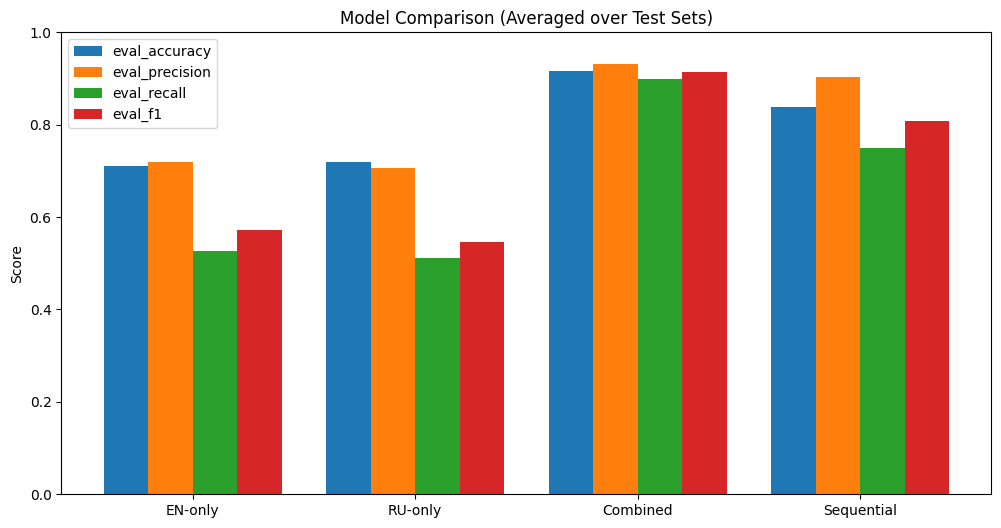

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]

models = results_df["Model"].unique()
tests = ["EN", "RU"]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))

for i, metric in enumerate(metrics):
    values = []

    for model in models:
        val = results_df[results_df["Model"] == model][metric].mean()
        values.append(val)

    ax.bar(x + (i - 1.5)*width, values, width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)

ax.set_title("Model Comparison (Averaged over Test Sets)")
ax.set_ylabel("Score")
ax.legend()

plt.show()

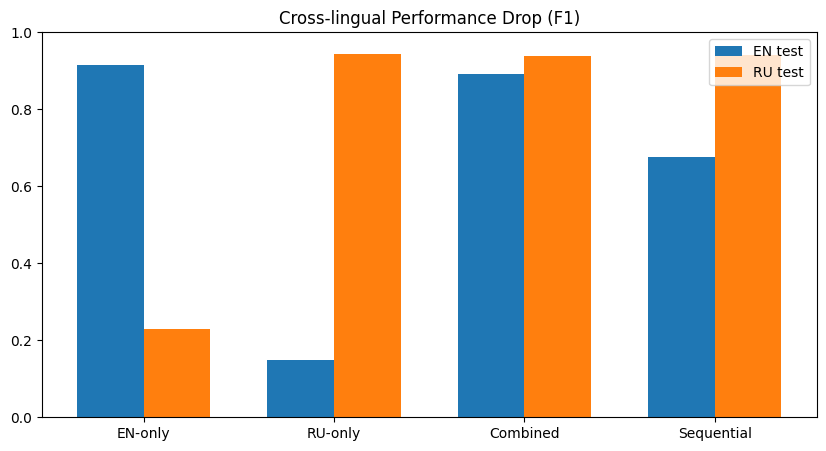

In [ ]:
import matplotlib.pyplot as plt

drop_df = pd.DataFrame({
    "Model": ["EN-only", "RU-only", "Combined", "Sequential"],
    "EN": [
        en_on_en["eval_f1"],
        ru_on_en["eval_f1"],
        combined_on_en["eval_f1"],
        seq_on_en["eval_f1"]
    ],
    "RU": [
        en_on_ru["eval_f1"],
        ru_on_ru["eval_f1"],
        combined_on_ru["eval_f1"],
        seq_on_ru["eval_f1"]
    ]
})

x = np.arange(len(drop_df["Model"]))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, drop_df["EN"], width, label="EN test")
plt.bar(x + width/2, drop_df["RU"], width, label="RU test")

plt.xticks(x, drop_df["Model"])
plt.ylim(0, 1)

plt.title("Cross-lingual Performance Drop (F1)")
plt.legend()

plt.show()

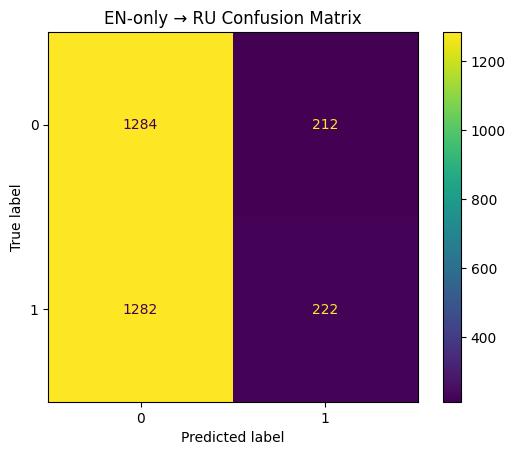

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_en_on_ru = trainer_en.predict(test_ru_ds)

y_true = preds_en_on_ru.label_ids
y_pred = np.argmax(preds_en_on_ru.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("EN-only → RU Confusion Matrix")
plt.show()

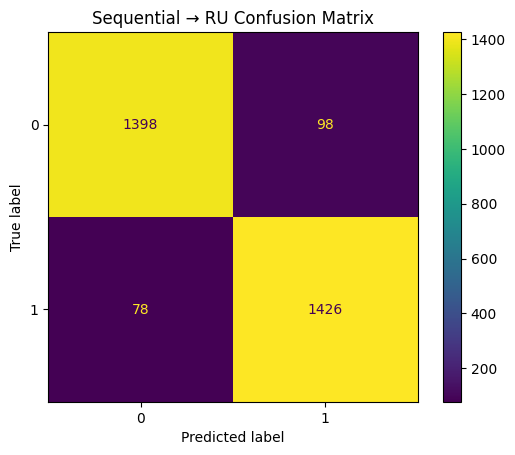

In [ ]:
preds_seq_on_ru = trainer_seq.predict(test_ru_ds)

y_true = preds_seq_on_ru.label_ids
y_pred = np.argmax(preds_seq_on_ru.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Sequential → RU Confusion Matrix")
plt.show()

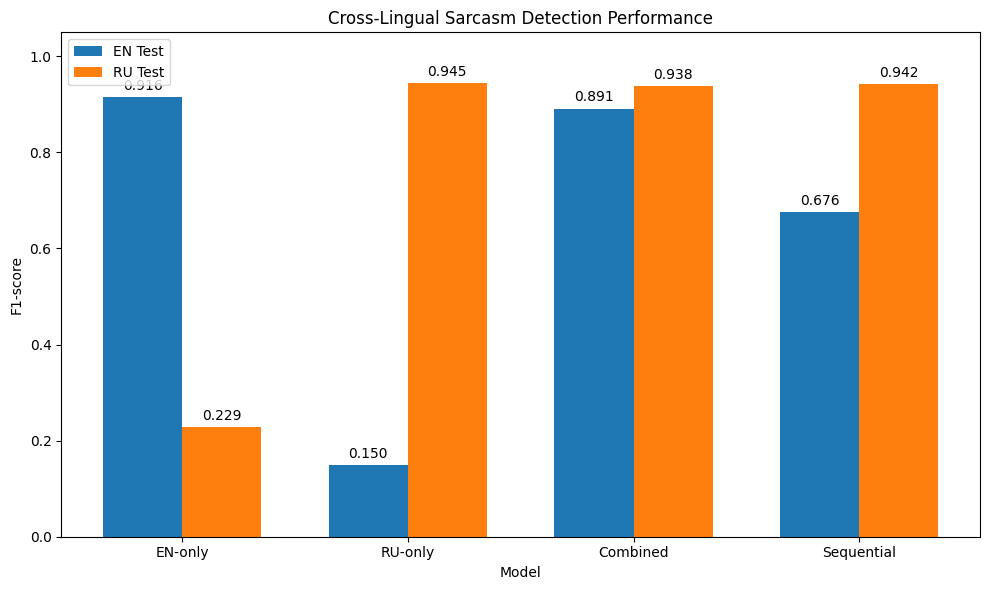

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pivot_df = results_df.pivot(
    index="Model",
    columns="Test",
    values="eval_f1"
)

pivot_df = pivot_df.loc[
    ["EN-only", "RU-only", "Combined", "Sequential"]
]

x = np.arange(len(pivot_df.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_en = ax.bar(
    x - width/2,
    pivot_df["EN"],
    width,
    label="EN Test"
)

bars_ru = ax.bar(
    x + width/2,
    pivot_df["RU"],
    width,
    label="RU Test"
)

ax.set_title("Cross-Lingual Sarcasm Detection Performance")
ax.set_xlabel("Model")
ax.set_ylabel("F1-score")

ax.set_xticks(x)
ax.set_xticklabels(pivot_df.index)

ax.set_ylim(0, 1.05)

ax.legend()

for bars in [bars_en, bars_ru]:
    for bar in bars:
        height = bar.get_height()

        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

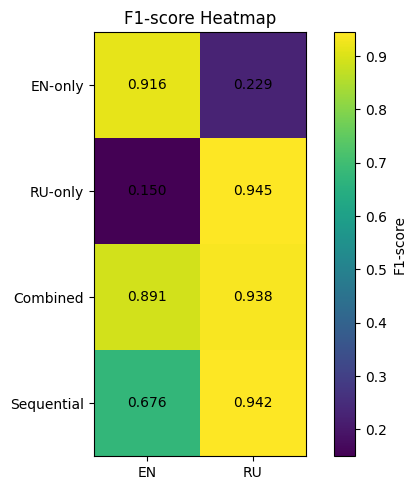

In [ ]:
import matplotlib.pyplot as plt

heatmap_df = results_df.pivot(
    index="Model",
    columns="Test",
    values="eval_f1"
)

heatmap_df = heatmap_df.loc[
    ["EN-only", "RU-only", "Combined", "Sequential"]
]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(heatmap_df.values)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)

ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        ax.text(
            j,
            i,
            f"{heatmap_df.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

ax.set_title("F1-score Heatmap")

cbar = plt.colorbar(im)
cbar.set_label("F1-score")

plt.tight_layout()
plt.show()

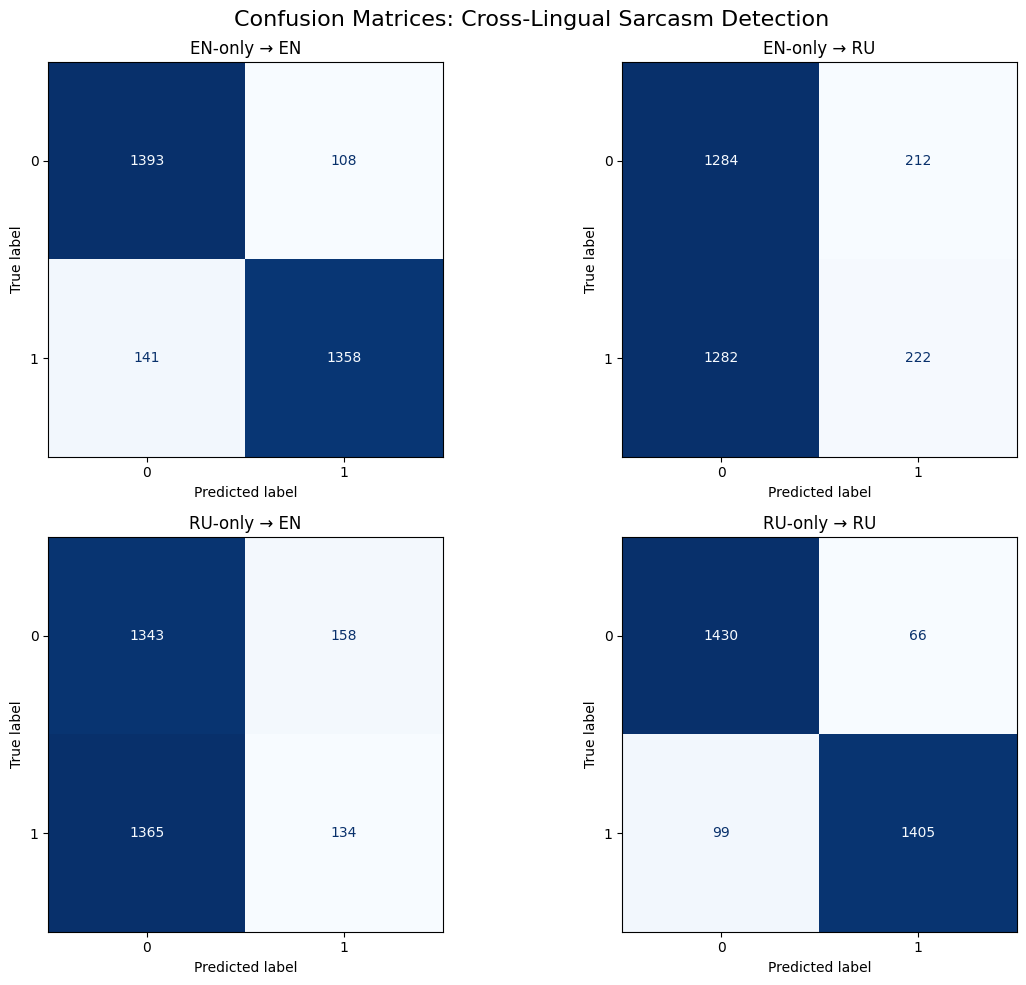

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def get_pred_labels(preds):
    return preds.predictions.argmax(axis=1)

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(title)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# For EN-only model
en_only_en_preds = trainer_en.predict(test_en_ds)
en_only_ru_preds = trainer_en.predict(test_ru_ds)

# For RU-only model
ru_only_en_preds = trainer_ru.predict(test_en_ds)
ru_only_ru_preds = trainer_ru.predict(test_ru_ds)


plot_cm(
    axes[0, 0],
    en_only_en_preds.label_ids,
    get_pred_labels(en_only_en_preds),
    "EN-only → EN"
)


plot_cm(
    axes[0, 1],
    en_only_ru_preds.label_ids,
    get_pred_labels(en_only_ru_preds),
    "EN-only → RU"
)

plot_cm(
    axes[1, 0],
    ru_only_en_preds.label_ids,
    get_pred_labels(ru_only_en_preds),
    "RU-only → EN"
)

plot_cm(
    axes[1, 1],
    ru_only_ru_preds.label_ids,
    get_pred_labels(ru_only_ru_preds),
    "RU-only → RU"
)


plt.suptitle("Confusion Matrices: Cross-Lingual Sarcasm Detection", fontsize=16)
plt.tight_layout()
plt.show()

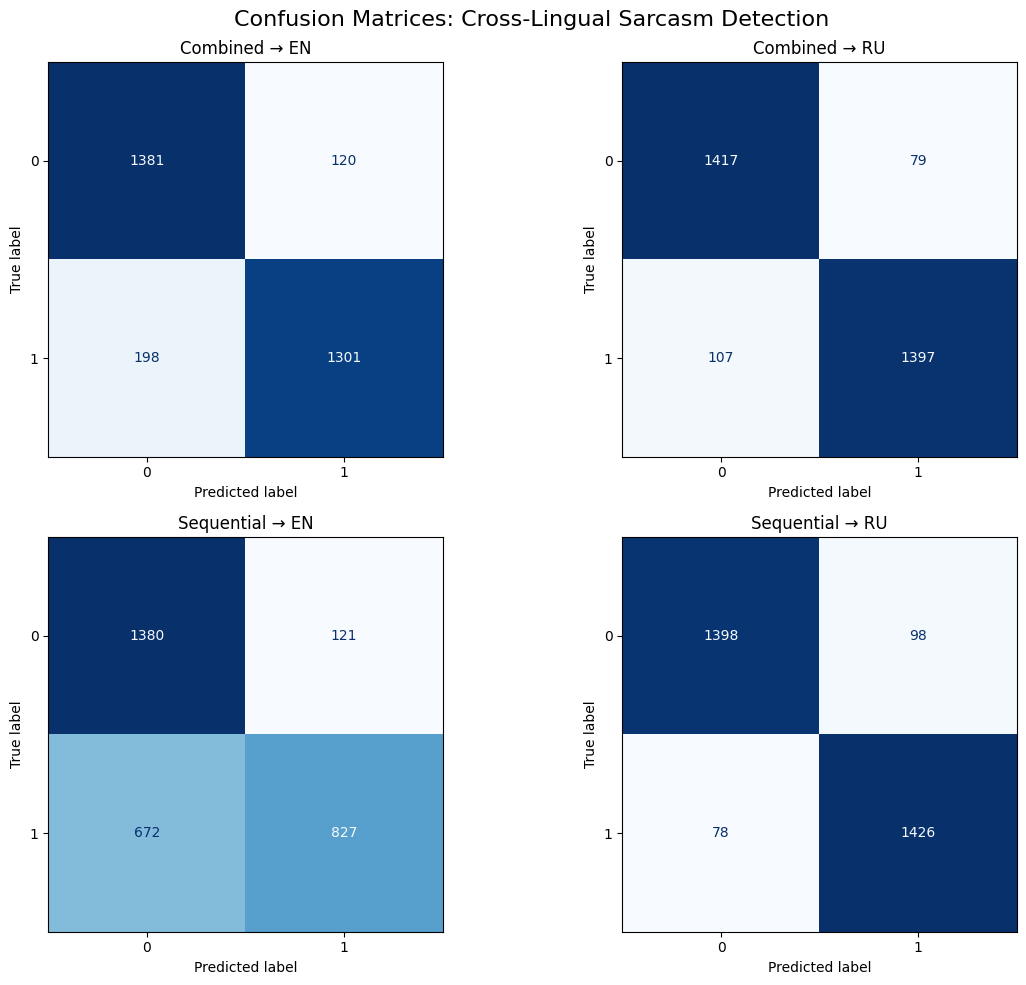

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def get_pred_labels(preds):
    return preds.predictions.argmax(axis=1)

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(title)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

combined_en_preds = trainer_combined.predict(test_en_ds)
combined_ru_preds = trainer_combined.predict(test_ru_ds)

seq_en_preds = trainer_seq.predict(test_en_ds)
seq_ru_preds = trainer_seq.predict(test_ru_ds)


plot_cm(
    axes[0, 0],
    combined_en_preds.label_ids,
    get_pred_labels(combined_en_preds),
    "Combined → EN"
)


plot_cm(
    axes[0, 1],
    combined_ru_preds.label_ids,
    get_pred_labels(combined_ru_preds),
    "Combined → RU"
)

plot_cm(
    axes[1, 0],
    seq_en_preds.label_ids,
    get_pred_labels(seq_en_preds),
    "Sequential → EN"
)

plot_cm(
    axes[1, 1],
    seq_ru_preds.label_ids,
    get_pred_labels(seq_ru_preds),
    "Sequential → RU"
)


plt.suptitle("Confusion Matrices: Cross-Lingual Sarcasm Detection", fontsize=16)
plt.tight_layout()
plt.show()



**Visualization**

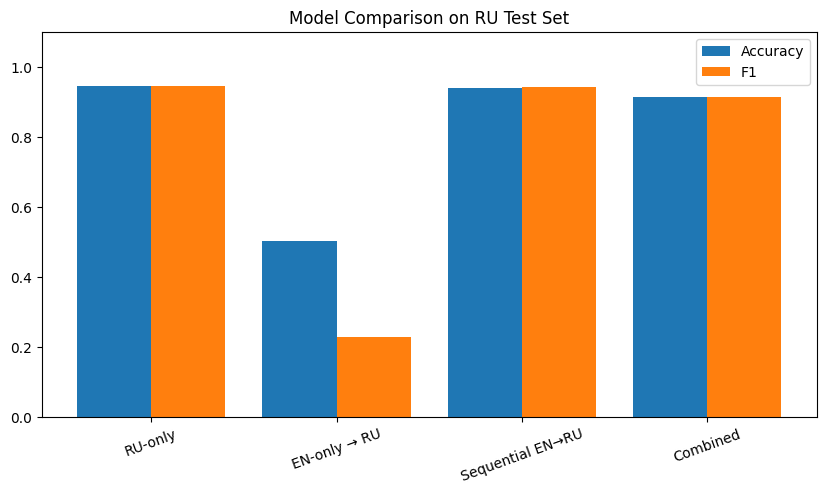

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "RU-only",
    "EN-only → RU",
    "Sequential EN→RU",
    "Combined"
]

accuracy = [
    0.9466,   # RU-only
    0.5016,   # EN-only on RU
    0.9413,   # sequential RU
    0.9156    # combined
]

f1 = [
    0.9463,
    0.2281,
    0.9418,
    0.9142
]

x = np.arange(len(models))

plt.figure(figsize=(10,5))

plt.bar(x - 0.2, accuracy, width=0.4, label="Accuracy")
plt.bar(x + 0.2, f1, width=0.4, label="F1")

plt.xticks(x, models, rotation=20)
plt.ylim(0, 1.1)
plt.title("Model Comparison on RU Test Set")
plt.legend()

plt.show()

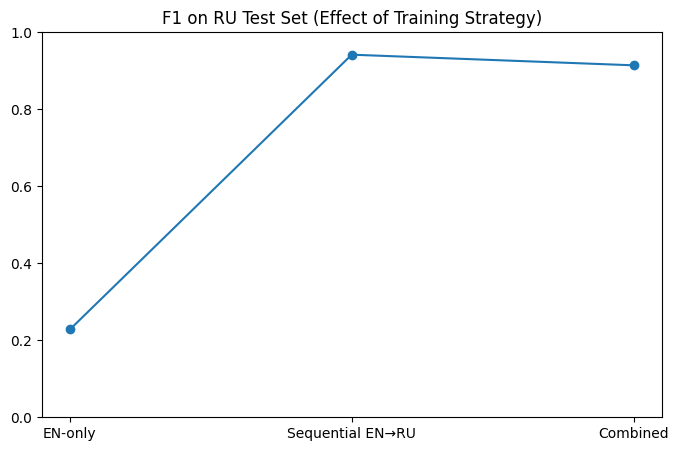

In [ ]:
models = ["EN-only", "Sequential EN→RU", "Combined"]

f1_ru = [0.2281, 0.9418, 0.9142]

plt.figure(figsize=(8,5))

plt.plot(models, f1_ru, marker='o')

plt.title("F1 on RU Test Set (Effect of Training Strategy)")
plt.ylim(0, 1)

plt.show()

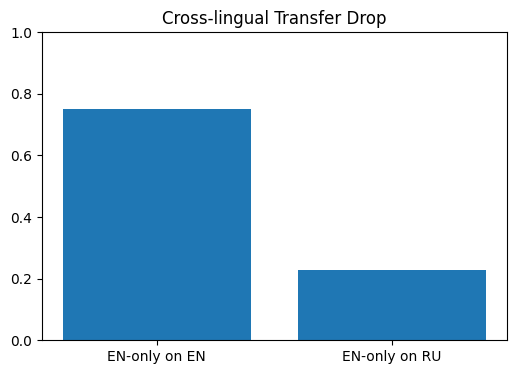

In [ ]:
models = ["EN-only on EN", "EN-only on RU"]

f1 = [0.75, 0.2281]

plt.figure(figsize=(6,4))

plt.bar(models, f1)

plt.title("Cross-lingual Transfer Drop")
plt.ylim(0, 1)

plt.show()

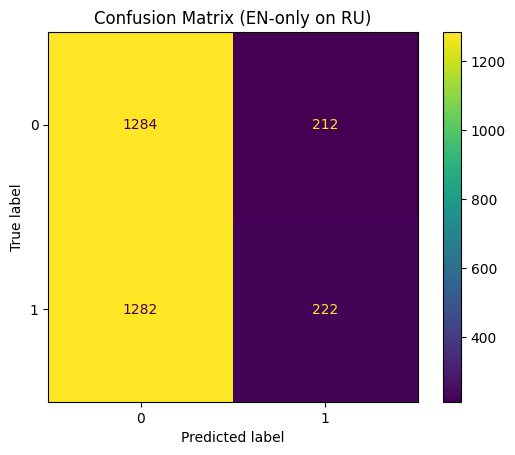

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds_en_on_ru = trainer_en.predict(test_ru_ds)

y_true = preds_en_on_ru.label_ids
y_pred = np.argmax(preds_en_on_ru.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title("Confusion Matrix (EN-only on RU)")
plt.show()

# **Part 2**

Model: https://huggingface.co/docs/transformers/model_doc/nllb

Dataset EN: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection

# **Part 3**

**Model (the best from Part 1):**

**Dataset (MT EN->RU):**

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [ ]:
translated_path = "/content/drive/MyDrive/sarcasm_thesis/data/test_en_translated_ru.csv"

df_translated = pd.read_csv(translated_path)

df_translated.head()

,text,label,translated_text
0,robots speak out against asimov's first law of...,1,Роботы выступают против первого закона роботот...
1,australian ambassador gets engaged in paris an...,0,Австралийский посол занимается Парижем и дает ...
2,michele bachmann thankful no americans died in...,1,"Мишель Бахманн благодарен, что не было америка..."
3,white house guidance counselor recommends clin...,1,Советник по рекомендациям в Белом доме рекомен...
4,a quick guide to this year's oscar best pictur...,0,Быстрый справочник к номинированным на этот го...


In [ ]:
df_translated.columns

Index(['text', 'label', 'translated_text'], dtype='object')

In [ ]:
BASE_PATH = "/content/drive/MyDrive/sarcasm_thesis"

model_path = f"{BASE_PATH}/models/combined_only"

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Using device: cuda


In [ ]:
eval_df = df_translated[["translated_text", "label"]].copy()

eval_df = eval_df.rename(columns={
    "translated_text": "text"
})

eval_df["text"] = eval_df["text"].fillna("").astype(str)
eval_df["label"] = eval_df["label"].astype(int)

translated_ds = Dataset.from_pandas(eval_df)

In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

translated_ds = translated_ds.map(tokenize_function, batched=True)

translated_ds = translated_ds.remove_columns(["text"])
translated_ds.set_format("torch")

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

eval_args = TrainingArguments(
    output_dir="./tmp_eval_translated",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_translated = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
!pip install numpy==1.26.4 --force-reinstall

translated_results = trainer_translated.evaluate(translated_ds)

translated_results

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is 

{'eval_loss': 2.9126060009002686,
 'eval_model_preparation_time': 0.0048,
 'eval_accuracy': 0.5956666666666667,
 'eval_precision': 0.8592964824120602,
 'eval_recall': 0.22815210140093395,
 'eval_f1': 0.36056931997891406,
 'eval_runtime': 9.275,
 'eval_samples_per_second': 323.449,
 'eval_steps_per_second': 20.269}

In [ ]:
pred_output = trainer_translated.predict(translated_ds)

logits = pred_output.predictions
true_labels = pred_output.label_ids

pred_labels = logits.argmax(axis=1)

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

prob_non_sarcastic = probs[:, 0]
prob_sarcastic = probs[:, 1]

In [ ]:
save_predictions_path = f"{BASE_PATH}/data/test_en_translated_ru_with_predictions.csv"

df_translated.to_csv(save_predictions_path, index=False)

print("Saved:", save_predictions_path)

Saved: /content/drive/MyDrive/sarcasm_thesis/data/test_en_translated_ru_with_predictions.csv


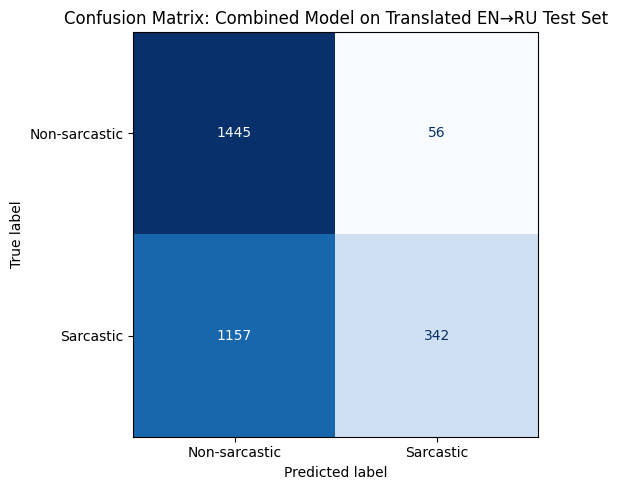

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-sarcastic", "Sarcastic"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title("Confusion Matrix: Combined Model on Translated EN→RU Test Set")

plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(
    true_labels,
    pred_labels,
    target_names=["Non-sarcastic", "Sarcastic"]
))

               precision    recall  f1-score   support

Non-sarcastic       0.56      0.96      0.70      1501
    Sarcastic       0.86      0.23      0.36      1499

     accuracy                           0.60      3000
    macro avg       0.71      0.60      0.53      3000
 weighted avg       0.71      0.60      0.53      3000



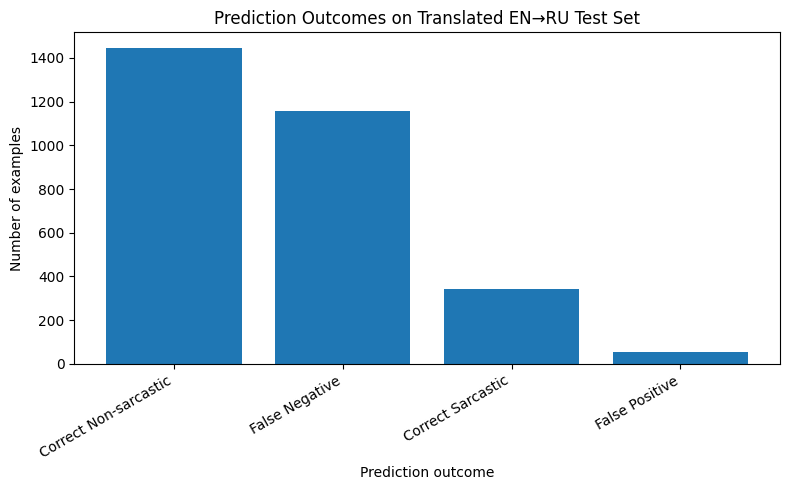

In [ ]:
df_translated["error_type"] = ""

df_translated.loc[(true_labels == 1) & (pred_labels == 1), "error_type"] = "Correct Sarcastic"
df_translated.loc[(true_labels == 0) & (pred_labels == 0), "error_type"] = "Correct Non-sarcastic"
df_translated.loc[(true_labels == 0) & (pred_labels == 1), "error_type"] = "False Positive"
df_translated.loc[(true_labels == 1) & (pred_labels == 0), "error_type"] = "False Negative"

error_counts = df_translated["error_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(error_counts.index, error_counts.values)

ax.set_title("Prediction Outcomes on Translated EN→RU Test Set")
ax.set_ylabel("Number of examples")
ax.set_xlabel("Prediction outcome")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

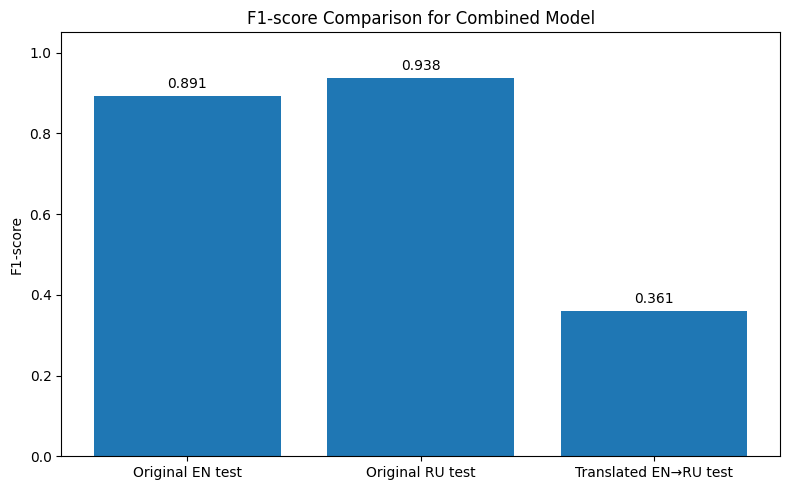

In [ ]:
combined_on_en = {'eval_f1': 0.8910958904109589}
combined_on_ru = {'eval_f1': 0.9375838926174497}

f1_comparison = pd.DataFrame({
    "Dataset": [
        "Original EN test",
        "Original RU test",
        "Translated EN→RU test"
    ],
    "F1": [
        combined_on_en["eval_f1"],
        combined_on_ru["eval_f1"],
        translated_results["eval_f1"]
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
f1_comparison["Dataset"],
    f1_comparison["F1"]
)

ax.set_title("F1-score Comparison for Combined Model")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)

for i, value in enumerate(f1_comparison["F1"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
df_translated["predicted_label"] = pred_labels
df_translated["prob_sarcastic"] = prob_sarcastic

preserved_sarcasm = df_translated[
    (df_translated["label"] == 1) &
    (df_translated["predicted_label"] == 1)
]

preserved_sarcasm[[
    "text",
    "translated_text",
    "label",
    "predicted_label",
    "prob_sarcastic"
]].head(100)

,text,translated_text,label,predicted_label,prob_sarcastic
5,report: it a miracle nothing has punctured you...,"Отчет: это чудо, что ничто еще не прорвало теб...",1,1,0.998530
6,ice cube thrown into sink flies up side like s...,"Кубик льда, брошенный в раковину, летит вверх,...",1,1,0.990067
12,tan asshole still on island time,Бедный дурак все еще на острове.,1,1,0.974460
15,"straight, gay service members looking forward ...","Гей-служащие с нетерпением ждут, когда спросят...",1,1,0.993938
22,coworker who just threw fit and stormed out of...,"Коллега, который просто бросил форму и вырвалс...",1,1,0.556554
...,...,...,...,...,...
819,george clooney beginning to think he should bu...,"Джордж Клуни начинает думать, что он должен ку...",1,1,0.829831
820,family chooses different dog than reincarnated...,"Семья выбирает другого собаки, чем реинкарниро...",1,1,0.985456
827,area man can't wait to get home to look out ne...,"Человек с нетерпением ждет, когда он вернется ...",1,1,0.530120
828,sources: nfl knew what evil lurking within hea...,"Источники: nfl знал, что зло скрывается в серд...",1,1,0.998841


In [ ]:
df_translated["predicted_label"] = pred_labels
df_translated["prob_sarcastic"] = prob_sarcastic

preserved_sarcasm = df_translated[
    (df_translated["label"] == 1) &
    (df_translated["predicted_label"] == 0)
]

preserved_sarcasm[[
    "text",
    "translated_text",
    "label",
    "predicted_label",
    "prob_sarcastic"
]].head(100)

,text,translated_text,label,predicted_label,prob_sarcastic
0,robots speak out against asimov's first law of...,Роботы выступают против первого закона роботот...,1,0,0.000176
2,michele bachmann thankful no americans died in...,"Мишель Бахманн благодарен, что не было америка...",1,0,0.000425
3,white house guidance counselor recommends clin...,Советник по рекомендациям в Белом доме рекомен...,1,0,0.000293
8,history channel admits to profiting from nazi ...,"History Channel признается, что получает прибы...",1,0,0.000675
9,blotting of ken olin from human memory delayed...,Удаление Кен Олина из человеческой памяти затя...,1,0,0.000213
...,...,...,...,...,...
216,monopoly releases special 'regular monopoly' e...,"Monopoly выпускает специальное издание ""Регуля...",1,0,0.000223
218,climate experts say only hope for saving plane...,"По мнению экспертов по климату, единственная н...",1,0,0.000487
229,lucky bastard gets to be in coma,Бедный ублюдок попал в коме.,1,0,0.000185
231,man listening to 'highway to hell' actually on...,"Слушая ""Шоссе к человеку в ад"" на самом деле н...",1,0,0.000255
